In [1]:
import numpy as np
import pandas as pd
import decoupler as dc
import matplotlib.pyplot as plt

print("Environment ready! All tools loaded.")

e:\biosensor_cfRNA_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready! All tools loaded.


In [2]:
# Set random seed so results are reproducible
np.random.seed(42)

# Define sample names: 5 Healthy controls, 5 Disease patients
samples = [f"Healthy_{i}" for i in range(1, 6)] + [f"Disease_{i}" for i in range(1, 6)]

# Define 20 realistic biomarker candidate genes (including known secreted/cfRNA targets)
# e.g., IL6, TNF, VEGFA, EGFR are key signaling targets often detected in liquid biopsies
genes = [
    "IL6", "TNF", "VEGFA", "EGFR", "TP53", "STAT3", "MMP9", "CXCL8", 
    "ACTB", "GAPDH", "ALB", "KRAS", "MYC", "PTEN", "CD44", 
    "CASP3", "HIF1A", "TGFB1", "FN1", "ESR1"
]

# Generate baseline expression counts
counts = np.random.poisson(lam=100, size=(len(genes), len(samples)))

# Simulate disease changes: make IL6, TNF, VEGFA, MMP9 significantly spiked in Disease samples
disease_spiked_indices = [0, 1, 2, 6]  # IL6, TNF, VEGFA, MMP9
for idx in disease_spiked_indices:
    counts[idx, 5:] = counts[idx, 5:] * np.random.uniform(3.5, 6.0, size=5)

# Convert to DataFrame
counts_df = pd.DataFrame(counts, index=genes, columns=samples)

# Create sample metadata (specifying who is Healthy vs Disease)
metadata = pd.DataFrame({
    "Condition": ["Healthy"] * 5 + ["Disease"] * 5
}, index=samples)

print("RNA-seq Counts Matrix Preview (First 5 Genes):")
print(counts_df.head())
print("\nSample Metadata Preview:")
print(metadata)

RNA-seq Counts Matrix Preview (First 5 Genes):
       Healthy_1  Healthy_2  Healthy_3  Healthy_4  Healthy_5  Disease_1  \
IL6           96        107         88        103        111        365   
TNF           99         90        103        103         94        601   
VEGFA        103         84         76         97        111        550   
EGFR          96        113         95         94        107        114   
TP53          94        116         97         91         94        118   

       Disease_2  Disease_3  Disease_4  Disease_5  
IL6          555        345        610        339  
TNF          414        550        346        493  
VEGFA        418        547        555        500  
EGFR          86        108        108        101  
TP53         104        110        115         94  

Sample Metadata Preview:
          Condition
Healthy_1   Healthy
Healthy_2   Healthy
Healthy_3   Healthy
Healthy_4   Healthy
Healthy_5   Healthy
Disease_1   Disease
Disease_2   Disease
Dise

In [3]:
from scipy import stats

results = []

# Separate Healthy and Disease column names
healthy_cols = metadata[metadata["Condition"] == "Healthy"].index
disease_cols = metadata[metadata["Condition"] == "Disease"].index

for gene in counts_df.index:
    healthy_vals = counts_df.loc[gene, healthy_cols].values
    disease_vals = counts_df.loc[gene, disease_cols].values
    
    # Calculate means
    mean_healthy = np.mean(healthy_vals)
    mean_disease = np.mean(disease_vals)
    
    # Calculate log2 fold change (adding 1 to prevent division by zero)
    log2fc = np.log2((mean_disease + 1) / (mean_healthy + 1))
    
    # Calculate statistical p-value
    _, pval = stats.ttest_ind(disease_vals, healthy_vals, equal_var=False)
    
    results.append({
        "gene": gene,
        "mean_healthy": mean_healthy,
        "mean_disease": mean_disease,
        "log2fc": log2fc,
        "pvalue": pval,
        "-log10_pval": -np.log10(pval if pval > 0 else 1e-10)
    })

deg_results = pd.DataFrame(results).set_index("gene")

# Sort by most significantly changed (smallest p-value first)
deg_results = deg_results.sort_values(by="pvalue")

print("Top 5 Differentially Expressed Candidates:")
print(deg_results[["log2fc", "pvalue", "-log10_pval"]].head())

Top 5 Differentially Expressed Candidates:
         log2fc    pvalue  -log10_pval
gene                                  
VEGFA  2.435539  0.000044     4.358935
TNF    2.285851  0.001098     2.959349
MMP9   2.182500  0.001747     2.757811
IL6    2.121341  0.004018     2.395990
TP53   0.135655  0.152999     0.815311


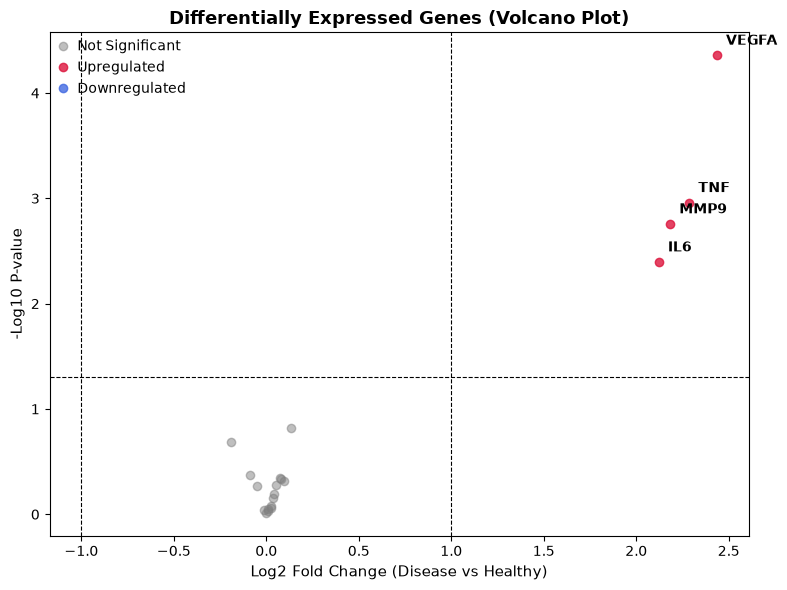

In [4]:
plt.figure(figsize=(8, 6))

# Define significance thresholds
fc_threshold = 1.0       # log2FC > 1 (at least 2-fold change)
pval_threshold = 0.05    # p-value < 0.05 (-log10(0.05) ~ 1.3)

# Filter categories
up = deg_results[(deg_results["log2fc"] >= fc_threshold) & (deg_results["pvalue"] < pval_threshold)]
down = deg_results[(deg_results["log2fc"] <= -fc_threshold) & (deg_results["pvalue"] < pval_threshold)]
ns = deg_results[(deg_results["pvalue"] >= pval_threshold) | (deg_results["log2fc"].abs() < fc_threshold)]

# Scatter plots for each category
plt.scatter(ns["log2fc"], ns["-log10_pval"], color="gray", alpha=0.5, label="Not Significant")
plt.scatter(up["log2fc"], up["-log10_pval"], color="crimson", alpha=0.8, label="Upregulated")
plt.scatter(down["log2fc"], down["-log10_pval"], color="royalblue", alpha=0.8, label="Downregulated")

# Label the top spiked biomarker genes on the plot
for gene in up.index[:4]:
    plt.text(
        up.loc[gene, "log2fc"] + 0.05, 
        up.loc[gene, "-log10_pval"] + 0.1, 
        gene, 
        fontsize=10, 
        weight="bold"
    )

# Threshold guideline lines
plt.axvline(x=fc_threshold, color="black", linestyle="--", linewidth=0.8)
plt.axvline(x=-fc_threshold, color="black", linestyle="--", linewidth=0.8)
plt.axhline(y=-np.log10(pval_threshold), color="black", linestyle="--", linewidth=0.8)

plt.title("Differentially Expressed Genes (Volcano Plot)", fontsize=13, weight="bold")
plt.xlabel("Log2 Fold Change (Disease vs Healthy)", fontsize=11)
plt.ylabel("-Log10 P-value", fontsize=11)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

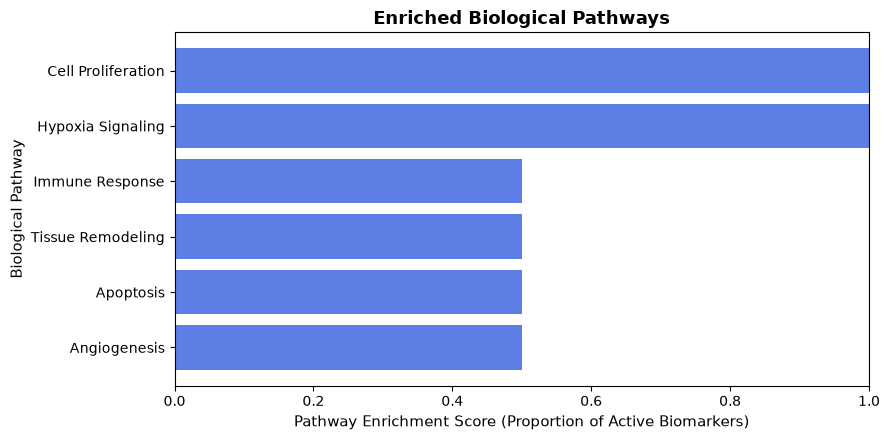

Ranked Enriched Pathways:
Hypoxia Signaling     1.0
Cell Proliferation    1.0
Apoptosis             0.5
Angiogenesis          0.5
Immune Response       0.5
Tissue Remodeling     0.5
dtype: float64


In [7]:
# 1. Define standard disease pathways and their member genes
pathway_network = pd.DataFrame([
    {"source": "Immune Response", "target": "IL6"},
    {"source": "Immune Response", "target": "TNF"},
    {"source": "Immune Response", "target": "CXCL8"},
    {"source": "Immune Response", "target": "STAT3"},
    {"source": "Angiogenesis", "target": "VEGFA"},
    {"source": "Angiogenesis", "target": "EGFR"},
    {"source": "Tissue Remodeling", "target": "MMP9"},
    {"source": "Tissue Remodeling", "target": "FN1"},
    {"source": "Apoptosis", "target": "CASP3"},
    {"source": "Apoptosis", "target": "TP53"},
    {"source": "Hypoxia Signaling", "target": "HIF1A"},
    {"source": "Cell Proliferation", "target": "MYC"}
])

# 2. Extract significant positive biomarkers
top_genes = set(deg_results[deg_results["log2fc"] > 0].head(10).index)

# 3. Calculate pathway overlap score directly
pathway_scores = {}
for pathway, group in pathway_network.groupby("source"):
    pathway_genes = set(group["target"])
    overlap = top_genes.intersection(pathway_genes)
    # Score = proportion of pathway genes found in top biomarkers
    pathway_scores[pathway] = len(overlap) / len(pathway_genes)

# Convert to series and sort
pathway_series = pd.Series(pathway_scores).sort_values(ascending=True)

# 4. Generate the Enriched Biological Pathways Horizontal Bar Plot
plt.figure(figsize=(9, 4.5))
plt.barh(pathway_series.index, pathway_series.values, color="royalblue", alpha=0.85)
plt.title("Enriched Biological Pathways", fontsize=13, weight="bold")
plt.xlabel("Pathway Enrichment Score (Proportion of Active Biomarkers)", fontsize=11)
plt.ylabel("Biological Pathway", fontsize=11)
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

print("Ranked Enriched Pathways:")
print(pathway_series.sort_values(ascending=False))

In [8]:
# Database of biosensor & liquid-biopsy compatibility annotations
# In clinical translation, markers must be secreted/extracellular to be sampled non-invasively
biosensor_annotation_db = pd.DataFrame([
    {"gene": "IL6", "secreted": True, "fluid": "Serum/Plasma/Saliva", "assay_type": "Aptamer / Lateral Flow Strip", "clinical_target": "Systemic Inflammation / Cytokine Storm"},
    {"gene": "TNF", "secreted": True, "fluid": "Serum/Plasma", "assay_type": "Lateral Flow Immunoassay", "clinical_target": "Autoimmune / Inflammatory Flare"},
    {"gene": "VEGFA", "secreted": True, "fluid": "Plasma/Urine", "assay_type": "Electrochemical Aptasensor", "clinical_target": "Tumor Angiogenesis / Vascular Stress"},
    {"gene": "MMP9", "secreted": True, "fluid": "Serum/Saliva", "assay_type": "Enzymatic Colorimetric Paper Test", "clinical_target": "Extracellular Matrix Breakdown"},
    {"gene": "CXCL8", "secreted": True, "fluid": "Serum/Sputum", "assay_type": "Lateral Flow Strip", "clinical_target": "Neutrophil Recruitment / Infection"},
    {"gene": "TP53", "secreted": False, "fluid": "Intracellular Only", "assay_type": "Not Viable for Paper POCT", "clinical_target": "Nuclear Transcription"},
    {"gene": "HIF1A", "secreted": False, "fluid": "Intracellular Only", "assay_type": "Not Viable for Paper POCT", "clinical_target": "Nuclear Transcription"},
    {"gene": "ACTB", "secreted": False, "fluid": "Intracellular Only", "assay_type": "Not Viable for Paper POCT", "clinical_target": "Cytoskeleton"},
    {"gene": "GAPDH", "secreted": False, "fluid": "Intracellular Only", "assay_type": "Not Viable for Paper POCT", "clinical_target": "Metabolism"}
]).set_index("gene")

# 1. Take top upregulated genes from differential expression (Step 9)
top_candidates = deg_results[deg_results["log2fc"] > 1.0].copy()

# 2. Merge with biosensor annotation database
biosensor_candidates = top_candidates.join(biosensor_annotation_db, how="inner")

# 3. Filter strictly for cell-free / secreted targets
final_panel = biosensor_candidates[biosensor_candidates["secreted"] == True].copy()
final_panel = final_panel.sort_values(by="log2fc", ascending=False)

# Display the final recommended biosensor panel
print("=====================================================================")
print("  TRANSLATIONAL BIOSENSOR CELL-FREE BIOMARKER PANEL (3-5 TARGETS)   ")
print("=====================================================================\n")
display_cols = ["log2fc", "pvalue", "fluid", "assay_type", "clinical_target"]
print(final_panel[display_cols].to_string())

  TRANSLATIONAL BIOSENSOR CELL-FREE BIOMARKER PANEL (3-5 TARGETS)   

         log2fc    pvalue                fluid                         assay_type                         clinical_target
gene                                                                                                                     
VEGFA  2.435539  0.000044         Plasma/Urine         Electrochemical Aptasensor    Tumor Angiogenesis / Vascular Stress
TNF    2.285851  0.001098         Serum/Plasma           Lateral Flow Immunoassay         Autoimmune / Inflammatory Flare
MMP9   2.182500  0.001747         Serum/Saliva  Enzymatic Colorimetric Paper Test          Extracellular Matrix Breakdown
IL6    2.121341  0.004018  Serum/Plasma/Saliva       Aptamer / Lateral Flow Strip  Systemic Inflammation / Cytokine Storm


In [9]:
import os

# Create an 'outputs' folder inside your project
os.makedirs("outputs", exist_ok=True)

# 1. Save the final translational biosensor table to a CSV file
final_panel.to_csv("outputs/recommended_biosensor_panel.csv")

# 2. Re-save Volcano Plot as a high-resolution image
plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(ns["log2fc"], ns["-log10_pval"], color="gray", alpha=0.5, label="Not Significant")
plt.scatter(up["log2fc"], up["-log10_pval"], color="crimson", alpha=0.8, label="Upregulated")
plt.scatter(down["log2fc"], down["-log10_pval"], color="royalblue", alpha=0.8, label="Downregulated")
for gene in up.index[:4]:
    plt.text(up.loc[gene, "log2fc"] + 0.05, up.loc[gene, "-log10_pval"] + 0.1, gene, fontsize=10, weight="bold")
plt.axvline(x=fc_threshold, color="black", linestyle="--", linewidth=0.8)
plt.axvline(x=-fc_threshold, color="black", linestyle="--", linewidth=0.8)
plt.axhline(y=-np.log10(pval_threshold), color="black", linestyle="--", linewidth=0.8)
plt.title("Differentially Expressed Genes (Volcano Plot)", fontsize=13, weight="bold")
plt.xlabel("Log2 Fold Change (Disease vs Healthy)", fontsize=11)
plt.ylabel("-Log10 P-value", fontsize=11)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("outputs/volcano_plot.png")
plt.close()

# 3. Re-save Pathway Plot as a high-resolution image
plt.figure(figsize=(9, 4.5), dpi=300)
plt.barh(pathway_series.index, pathway_series.values, color="royalblue", alpha=0.85)
plt.title("Enriched Biological Pathways", fontsize=13, weight="bold")
plt.xlabel("Pathway Enrichment Score", fontsize=11)
plt.ylabel("Biological Pathway", fontsize=11)
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig("outputs/pathway_enrichment.png")
plt.close()

print("All portfolio assets exported successfully into the 'outputs' folder!")

All portfolio assets exported successfully into the 'outputs' folder!
